In [1]:
# Core libraries for modeling and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: baseline models and error metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

STATE = "BY"

In [2]:
# Load the pre-built feature sets from Notebook 2 — no need to rebuild
# calendar/lag/rolling features here, they're already done and saved
train = pd.read_csv("../data/train_features.csv", index_col=0, parse_dates=True)
val = pd.read_csv("../data/val_features.csv", index_col=0, parse_dates=True)

print("Train:", train.shape, "|", train.index.min(), "to", train.index.max())
print("Val:  ", val.shape, "|", val.index.min(), "to", val.index.max())

Train: (30480, 18) | 2019-01-08 00:00:00 to 2022-06-30 23:00:00
Val:   (4416, 18) | 2022-07-01 00:00:00 to 2022-12-31 23:00:00


In [3]:
# Separate predictors from the target across both sets.
# demand_mwh is what we're predicting, so it can't appear in X.
target_col = "demand_mwh"
feature_cols = [c for c in train.columns if c != target_col]

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]

print("Features used:", feature_cols)
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:", y_val.shape)

Features used: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']
X_train: (30480, 17) | y_train: (30480,)
X_val:   (4416, 17) | y_val: (4416,)


In [4]:
from sklearn.metrics import r2_score

# Linear Regression — our simplest baseline. Gives us a floor to beat with
# more complex models, and its coefficients are directly interpretable
# (unlike Random Forest/XGBoost feature importances, which are less literal).
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the held-out validation set (Jul-Dec 2022, never seen during training)
lr_preds = lr_model.predict(X_val)

# Four metrics, each answering a different question:
# - MAE:  average error size, in the same units as demand (MWh) — easy to explain to a non-technical audience
# - RMSE: like MAE but penalizes big misses more heavily — exposes whether the model has occasional bad spikes
# - MAPE: error as a %, comparable across states of very different scale (Bavaria vs a small state)
# - R²:   how much of the demand's variance the model explains (1.0 = perfect, 0.0 = no better than
#         just predicting the average every time) — the "dependability" metric requested
lr_mae = mean_absolute_error(y_val, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
lr_mape = np.mean(np.abs((y_val - lr_preds) / y_val)) * 100
lr_r2 = r2_score(y_val, lr_preds)

print(f"Linear Regression")
print(f"  MAE:  {lr_mae:.1f} MWh")
print(f"  RMSE: {lr_rmse:.1f} MWh")
print(f"  MAPE: {lr_mape:.2f}%")
print(f"  R²:   {lr_r2:.4f}")

Linear Regression
  MAE:  318.2 MWh
  RMSE: 408.5 MWh
  MAPE: 3.77%
  R²:   0.9329


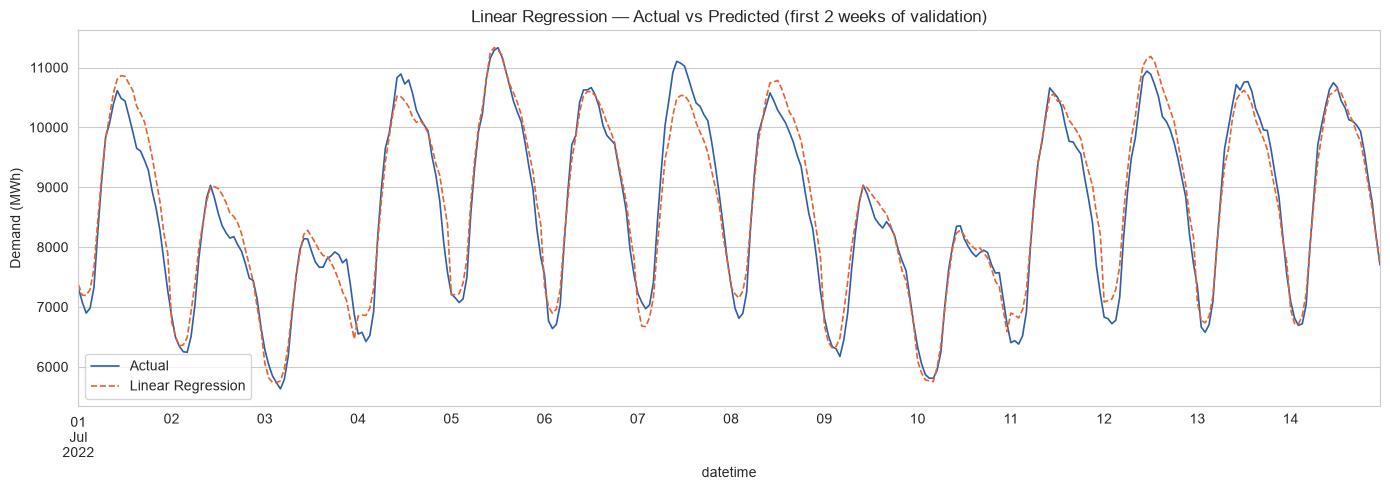

In [5]:
# Plot actual vs predicted for the first 2 weeks of the validation set —
# full 6 months would be too dense to read visually
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.2, color="#2E5EAA")
pd.Series(lr_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Linear Regression", linewidth=1.2, color="#E8622C", linestyle="--")
ax.set_title("Linear Regression — Actual vs Predicted (first 2 weeks of validation)")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Running comparison table — every model's metrics get appended here as we train them.
# This becomes the actual evidence for "which model is more ideal and why" in the README.
results = pd.DataFrame(columns=["MAE", "RMSE", "MAPE", "R2"])

results.loc["Linear Regression"] = [lr_mae, lr_rmse, lr_mape, lr_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866


In [7]:
# Random Forest — an ensemble of decision trees. Unlike Linear Regression, it can
# capture non-linear interactions (e.g. "weekend AND winter" behaving differently
# than weekend or winter alone) without us having to hand-engineer those interaction terms.
rf_model = RandomForestRegressor(
    n_estimators=200,     # number of trees — more trees = more stable predictions, diminishing returns past a point
    max_depth=15,         # caps tree depth to control overfitting on 30k training rows
    random_state=42,      # reproducibility
    n_jobs=-1              # use all available CPU cores to speed up training
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
rf_mape = np.mean(np.abs((y_val - rf_preds) / y_val)) * 100
rf_r2 = r2_score(y_val, rf_preds)

results.loc["Random Forest"] = [rf_mae, rf_rmse, rf_mape, rf_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866
Random Forest      227.553744  337.563637  2.585441  0.954156


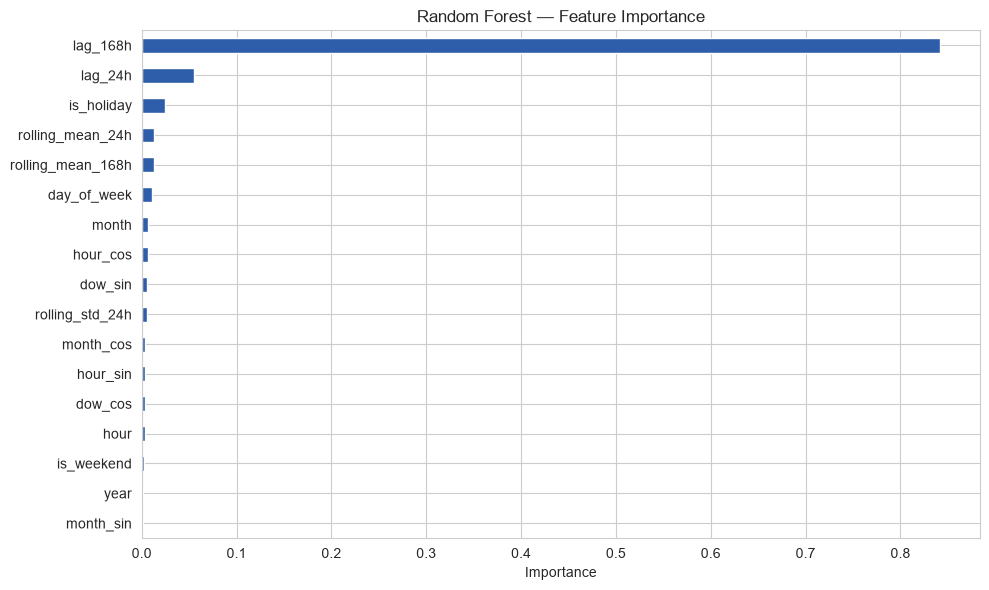

lag_168h             0.841740
lag_24h              0.055128
is_holiday           0.024785
rolling_mean_24h     0.013248
rolling_mean_168h    0.012856
day_of_week          0.010617
month                0.006807
hour_cos             0.006227
dow_sin              0.005905
rolling_std_24h      0.005587
month_cos            0.003244
hour_sin             0.003157
dow_cos              0.003045
hour                 0.003030
is_weekend           0.002686
year                 0.001011
month_sin            0.000930
dtype: float64


In [8]:
# Random Forest gives us feature importances "for free" — which features it
# actually leaned on to make predictions. Useful both as a sanity check
# (does it match the correlations we found in Notebook 2?) and as a talking
# point for the README (what actually drives the forecast).
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="barh", ax=ax, color="#2E5EAA")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance")
ax.invert_yaxis()  # highest importance at the top
plt.tight_layout()
plt.show()

print(importances)

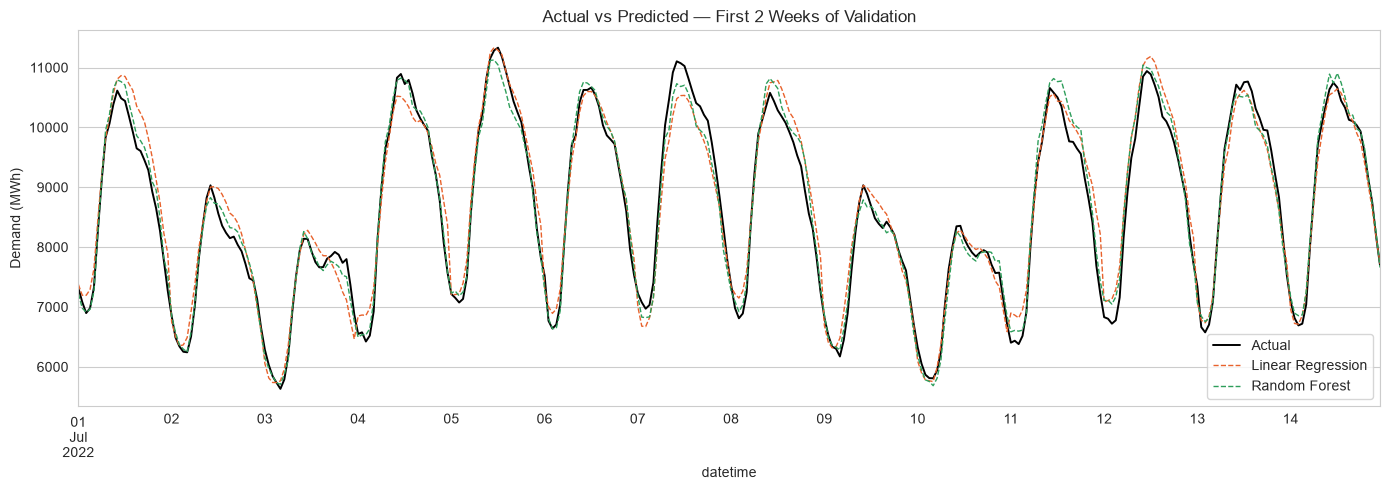

In [9]:
# Compare both models visually against actual demand — same first-2-weeks window as before
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.4, color="black")
pd.Series(lr_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Linear Regression", linewidth=1, color="#E8622C", linestyle="--")
pd.Series(rf_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Random Forest", linewidth=1, color="#2E9E5B", linestyle="--")
ax.set_title("Actual vs Predicted — First 2 Weeks of Validation")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** Random Forest confirms `lag_168h` (same hour, one week ago) as the dominant driver,
accounting for ~84% of feature importance — far ahead of `lag_24h` (~5%) and everything else. Notably,
calendar features like `is_weekend` and `hour` carry almost no importance here despite correlating
meaningfully with demand on their own (Notebook 2) — because `lag_168h` already implicitly captures
day-of-week and time-of-day patterns (a Tuesday 11am a week ago is still a Tuesday 11am). Random Forest
correctly recognizes these as redundant once it has the lag feature, rather than double-counting them.

In [12]:
from xgboost import XGBRegressor

# XGBoost — gradient boosting, builds trees sequentially where each new tree
# corrects the errors of the ones before it (vs. Random Forest's trees, which
# are built independently and averaged). Often edges out Random Forest on
# tabular data like this, though not always by much.
xgb_model = XGBRegressor(
    n_estimators=300,       # number of boosting rounds
    max_depth=6,             # shallower trees than RF since boosting compounds each tree's contribution
    learning_rate=0.05,      # how much each tree corrects the previous ones — lower = more conservative, less overfit-prone
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
xgb_mape = np.mean(np.abs((y_val - xgb_preds) / y_val)) * 100
xgb_r2 = r2_score(y_val, xgb_preds)

results.loc["XGBoost"] = [xgb_mae, xgb_rmse, xgb_mape, xgb_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866
Random Forest      227.553744  337.563637  2.585441  0.954156
XGBoost            201.169144  275.419305  2.335598  0.969482
